Dataset Head:
    Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type  \
0  2014           3.35           5.59       27000    Petrol      Dealer   
1  2013           4.75           9.54       43000    Diesel      Dealer   
2  2017           7.25           9.85        6900    Petrol      Dealer   
3  2011           2.85           4.15        5200    Petrol      Dealer   
4  2014           4.60           6.87       42450    Diesel      Dealer   

  Transmission  Owner  
0       Manual      0  
1       Manual      0  
2       Manual      0  
3       Manual      0  
4       Manual      0  

--- A. Linear Regression (Predicting Selling_Price) ---
Mean Squared Error: 3.478803970647689
R-squared Score: 0.8489813024894818


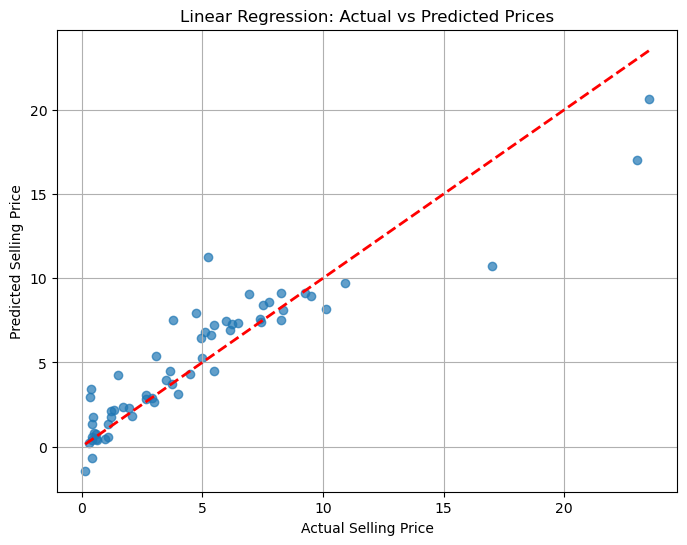


--- B. Logistic Regression (Predicting Transmission) ---
Accuracy: 0.8524590163934426
Confusion Matrix:
 [[50  1]
 [ 8  2]]


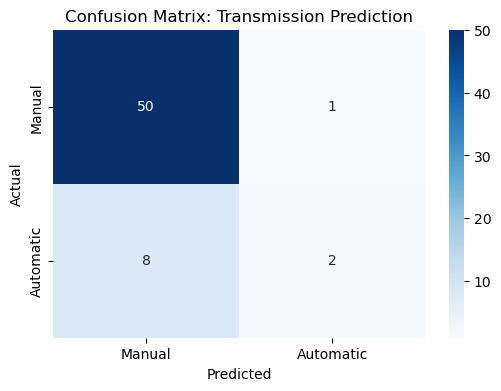

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

# ==========================================
# Common Data Loading & Preprocessing
# ==========================================
# Load dataset
df = pd.read_csv('linear_regression_data_v2.csv')

# Drop 'Car_Name' as it has too many unique string values for simple models
df = df.drop('Car_Name', axis=1)

print("Dataset Head:\n", df.head())

# ==========================================
# A. Linear Regression Implementation
# Goal: Predict 'Selling_Price'
# ==========================================
print("\n--- A. Linear Regression (Predicting Selling_Price) ---")

# 1. Prepare Data
# Convert categorical variables to numeric (One-Hot Encoding) for Linear Regression
df_linear = pd.get_dummies(df, drop_first=True)

# Define Features (X) and Target (y)
X_lin = df_linear.drop('Selling_Price', axis=1)
y_lin = df_linear['Selling_Price']

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

# 3. Model training
lr = LinearRegression()
lr.fit(X_train, y_train)

# 4. Prediction
y_pred = lr.predict(X_test)

# 5. Evaluation
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared Score:", lr.score(X_test, y_test))

# 6. Visualization
# Since we have multiple features, we plot Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.grid(True)
plt.show()


# ==========================================
# B. Logistic Regression Implementation
# Goal: Predict 'Transmission' (Manual=0 vs Automatic=1)
# ==========================================
print("\n--- B. Logistic Regression (Predicting Transmission) ---")

# 1. Prepare Data
# Target: Transmission. We encode it: Manual -> 0, Automatic -> 1
y_log = df['Transmission'].map({'Manual': 0, 'Automatic': 1})

# Features: Drop Transmission from input features
X_raw = df.drop('Transmission', axis=1)
# Encode the remaining categorical features (Fuel_Type, Seller_Type)
X_log = pd.get_dummies(X_raw, drop_first=True)

# 2. Train-test split
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

# 3. Model training
# Increased max_iter to ensure convergence
model = LogisticRegression(max_iter=5000)
model.fit(X_train_log, y_train_log)

# 4. Prediction
y_pred_log = model.predict(X_test_log)

# 5. Evaluation
accuracy = accuracy_score(y_test_log, y_pred_log)
cm = confusion_matrix(y_test_log, y_pred_log)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)

# Optional: Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Manual', 'Automatic'], yticklabels=['Manual', 'Automatic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Transmission Prediction')
plt.show()